<a href="https://colab.research.google.com/github/rishav1504/Bmf16-Arcade-Stenosis-ML/blob/main/bm616_stenosis_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Advanced EDA: Multi-Graph Comparisons

This section compares both tasks (`stenosis` and `syntax`) across `train`, `val`, and `test`.

You will get:
- Images and annotations count comparisons
- Annotations-per-image distribution comparisons
- Category count comparisons
- Polygon complexity comparisons

In [ ]:
# --- COCO helpers and paths (Your dataset specific) ---

from pathlib import Path
import json
from collections import defaultdict

# --- Mount Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- SET ROOT EXACTLY ---
project_root = Path('/content/drive/MyDrive/bm616/data')

ds_name = "stenosis"   # your dataset name


# --- Path utilities ---
def get_split_paths(root: Path, ds_name: str, split: str):
    img_dir = root / ds_name / split / 'images'
    ann_path = root / ds_name / split / 'annotations' / f'{split}.json'

    if not img_dir.exists():
        raise FileNotFoundError(f"Image directory not found: {img_dir}")
    if not ann_path.exists():
        raise FileNotFoundError(f"Annotation file not found: {ann_path}")

    return img_dir, ann_path


# --- Load COCO JSON ---
def load_coco_json(json_path: Path):
    with open(json_path, 'r', encoding='utf-8') as f:
        return json.load(f)


# --- Build image lookup ---
def build_image_lookup(coco_data):
    return {item['id']: item['file_name'] for item in coco_data['images']}


# --- Build annotations lookup ---
def build_annotations_lookup(coco_data):
    anns_lookup = defaultdict(list)
    for ann in coco_data['annotations']:
        anns_lookup[ann['image_id']].append(ann)
    return anns_lookup


# --- TEST IT (sanity check) ---
split = "train"  # change to val/test as needed

img_dir, ann_path = get_split_paths(project_root, ds_name, split)

coco_data = load_coco_json(ann_path)

image_lookup = build_image_lookup(coco_data)
anns_lookup = build_annotations_lookup(coco_data)

print(f"✅ Split: {split}")
print(f"📁 Image dir: {img_dir}")
print(f"📄 Annotation file: {ann_path}")
print(f"🖼️ Total images: {len(image_lookup)}")
print(f"🏷️ Annotated images: {len(anns_lookup)}")

Mounted at /content/drive
✅ Split: train
📁 Image dir: /content/drive/MyDrive/bm616/data/stenosis/train/images
📄 Annotation file: /content/drive/MyDrive/bm616/data/stenosis/train/annotations/train.json
🖼️ Total images: 1000
🏷️ Annotated images: 997


,task,split,images,annotations,categories,mean_annotations_per_image,median_annotations_per_image
2,stenosis,test,300,386,26,1.286667,1.0
0,stenosis,train,1000,1625,26,1.625000,1.0
1,stenosis,val,200,406,26,2.030000,2.0
5,syntax,test,300,1672,26,5.573333,5.0
3,syntax,train,1000,4976,26,4.976000,5.0
4,syntax,val,200,1168,26,5.840000,6.0


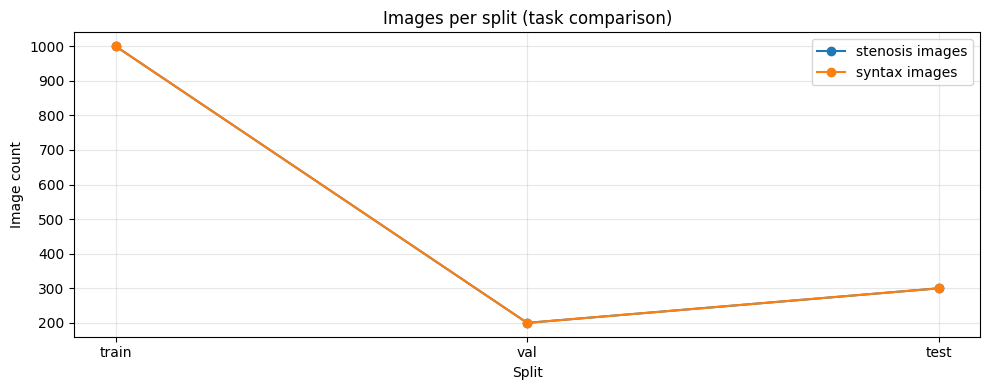

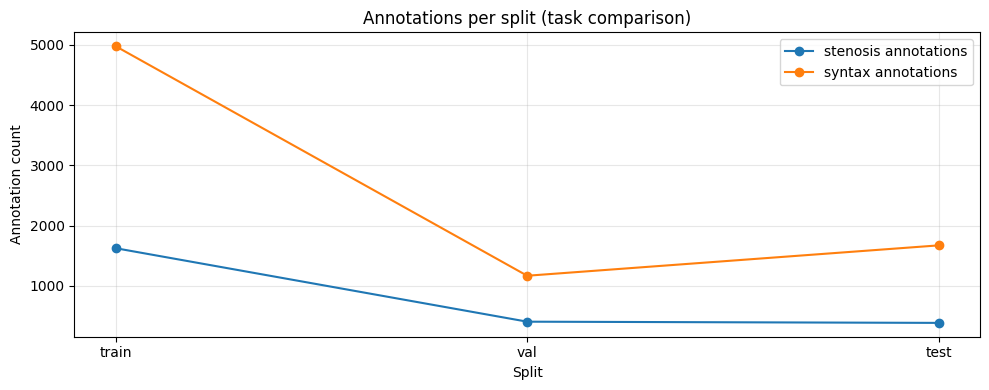

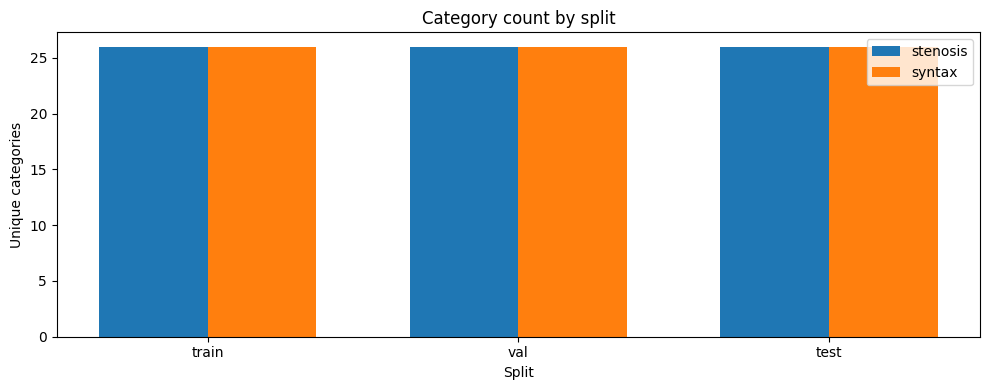

In [ ]:
# --- Load task + split safely ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_task_split(task_name, split_name):
    try:
        img_dir, ann_path = get_split_paths(project_root, task_name, split_name)
        coco = load_coco_json(ann_path)

        return {
            'task': task_name,
            'split': split_name,
            'img_dir': img_dir,
            'coco': coco,
            'image_lookup': build_image_lookup(coco),
            'anns_lookup': build_annotations_lookup(coco)
        }
    except Exception as e:
        print(f"⚠️ Skipping {task_name}-{split_name}: {e}")
        return None


# --- CONFIG ---
all_tasks = ['stenosis', 'syntax']   # NOW VALID
all_splits = ['train', 'val', 'test']


# --- Load all data ---
all_data = []
for task in all_tasks:
    for split in all_splits:
        data = load_task_split(task, split)
        if data is not None:
            all_data.append(data)


# --- Build summary table ---
summary_rows = []

for item in all_data:
    coco = item['coco']

    # Include ALL images (even with 0 annotations)
    anns_per_image = {img['id']: 0 for img in coco['images']}

    for ann in coco['annotations']:
        anns_per_image[ann['image_id']] += 1

    ann_counts = list(anns_per_image.values())

    summary_rows.append({
        'task': item['task'],
        'split': item['split'],
        'images': len(coco['images']),
        'annotations': len(coco['annotations']),
        'categories': len(coco.get('categories', [])),
        'mean_annotations_per_image': float(np.mean(ann_counts)) if ann_counts else 0.0,
        'median_annotations_per_image': float(np.median(ann_counts)) if ann_counts else 0.0
    })


# --- DataFrame ---
adv_summary_df = pd.DataFrame(summary_rows)
display(adv_summary_df.sort_values(['task', 'split']))


# --- Plot 1: Image count comparison ---
plt.figure(figsize=(10, 4))
for task in all_tasks:
    d = adv_summary_df[adv_summary_df['task'] == task].set_index('split').reindex(all_splits)
    plt.plot(all_splits, d['images'], marker='o', label=f'{task} images')

plt.title('Images per split (task comparison)')
plt.xlabel('Split')
plt.ylabel('Image count')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# --- Plot 2: Annotation count comparison ---
plt.figure(figsize=(10, 4))
for task in all_tasks:
    d = adv_summary_df[adv_summary_df['task'] == task].set_index('split').reindex(all_splits)
    plt.plot(all_splits, d['annotations'], marker='o', label=f'{task} annotations')

plt.title('Annotations per split (task comparison)')
plt.xlabel('Split')
plt.ylabel('Annotation count')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# --- Plot 3: Category count comparison (bar plot) ---
plt.figure(figsize=(10, 4))

x = np.arange(len(all_splits))
width = 0.35

for i, task in enumerate(all_tasks):
    d = adv_summary_df[adv_summary_df['task'] == task].set_index('split').reindex(all_splits)
    plt.bar(x + (i - len(all_tasks)/2)*width + width/2,
            d['categories'],
            width,
            label=task)

plt.xticks(x, all_splits)
plt.title('Category count by split')
plt.xlabel('Split')
plt.ylabel('Unique categories')
plt.legend()
plt.tight_layout()
plt.show()

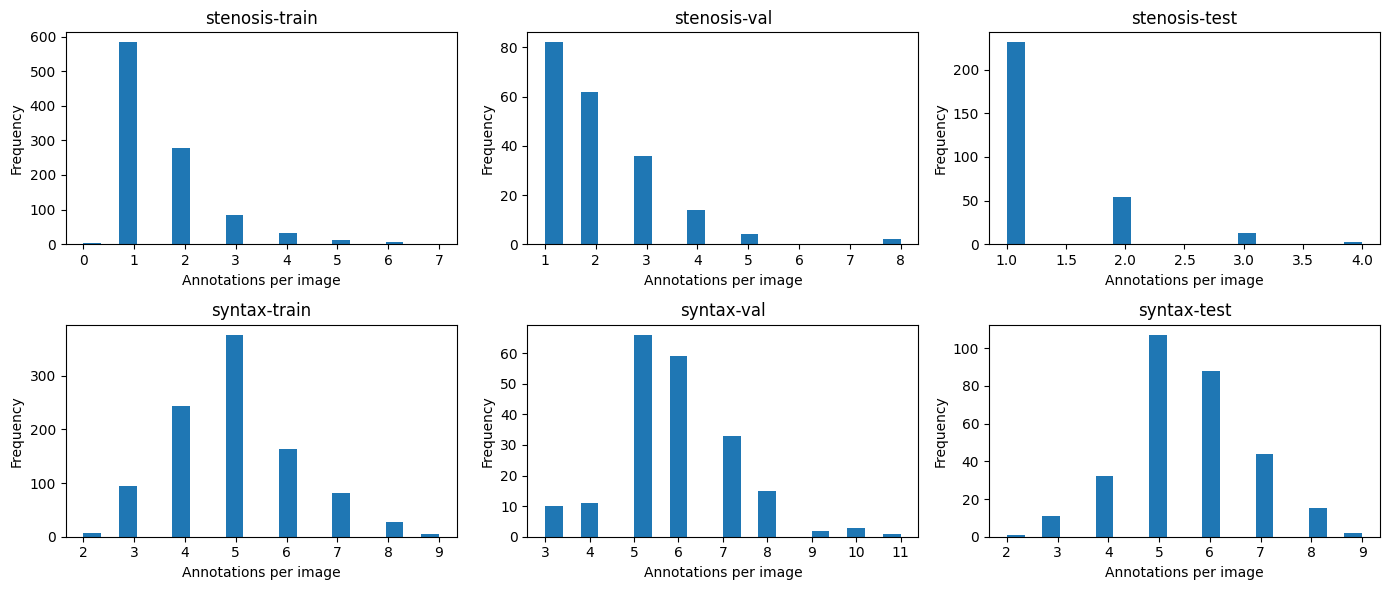

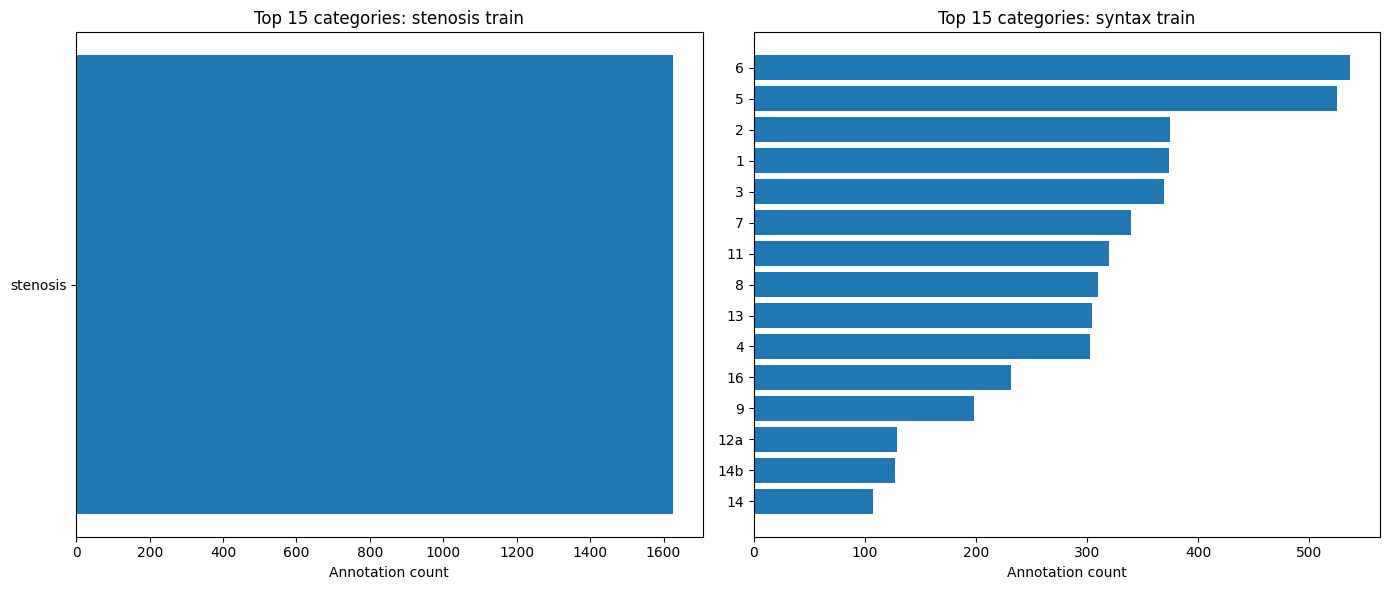

In [ ]:
# --- Plot 4: annotations per image distribution ---
plt.figure(figsize=(14, 6))

total_plots = len(all_tasks) * len(all_splits)
rows = len(all_tasks)
cols = len(all_splits)

plot_idx = 1

for task in all_tasks:
    for split in all_splits:
        # Safe fetch
        item = next((x for x in all_data if x['task'] == task and x['split'] == split), None)
        if item is None:
            continue

        coco = item['coco']

        # Include ALL images
        anns_per_image = {img['id']: 0 for img in coco['images']}
        for ann in coco['annotations']:
            anns_per_image[ann['image_id']] += 1

        values = list(anns_per_image.values())

        plt.subplot(rows, cols, plot_idx)
        plt.hist(values, bins=20)
        plt.title(f'{task}-{split}')
        plt.xlabel('Annotations per image')
        plt.ylabel('Frequency')

        plot_idx += 1

plt.tight_layout()
plt.show()

# --- Plot 5: top categories in train split ---
num_tasks = len(all_tasks)
fig, axes = plt.subplots(1, num_tasks, figsize=(7 * num_tasks, 6))

# Handle single task case
if num_tasks == 1:
    axes = [axes]

for ax, task in zip(axes, all_tasks):
    item = next((x for x in all_data if x['task'] == task and x['split'] == 'train'), None)

    if item is None:
        ax.set_title(f"{task} (missing)")
        continue

    coco = item['coco']
    cat_id_to_name = {c['id']: c['name'] for c in coco.get('categories', [])}

    cat_counts = {}
    for ann in coco['annotations']:
        cid = ann['category_id']
        cat_counts[cid] = cat_counts.get(cid, 0) + 1

    if len(cat_counts) == 0:
        ax.set_title(f"{task} (no annotations)")
        continue

    df = pd.DataFrame([
        {'category': cat_id_to_name.get(cid, str(cid)), 'count': cnt}
        for cid, cnt in cat_counts.items()
    ]).sort_values('count', ascending=False).head(15)

    ax.barh(df['category'].astype(str), df['count'])
    ax.invert_yaxis()
    ax.set_title(f'Top 15 categories: {task} train')
    ax.set_xlabel('Annotation count')

plt.tight_layout()
plt.show()

,task,split,mean_points,median_points,p90_points
2,stenosis,test,19.430052,17.0,32.5
0,stenosis,train,23.857846,18.0,46.0
1,stenosis,val,20.369458,17.0,31.0
5,syntax,test,91.656699,71.0,174.0
3,syntax,train,83.072146,61.5,176.0
4,syntax,val,79.702055,61.0,164.0


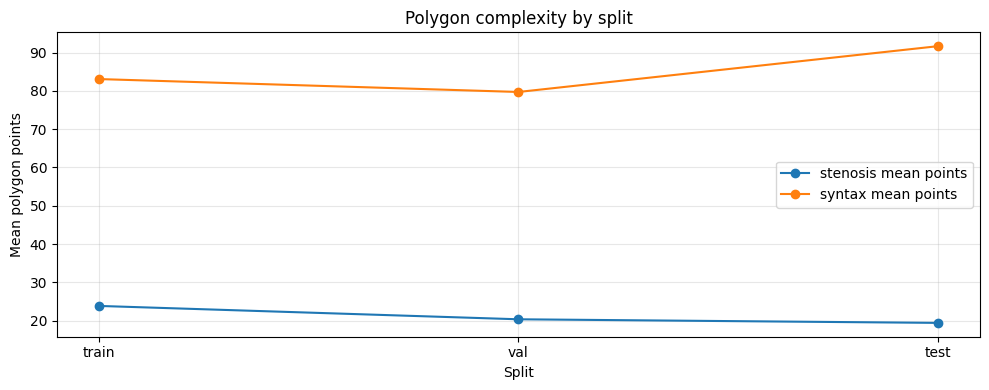

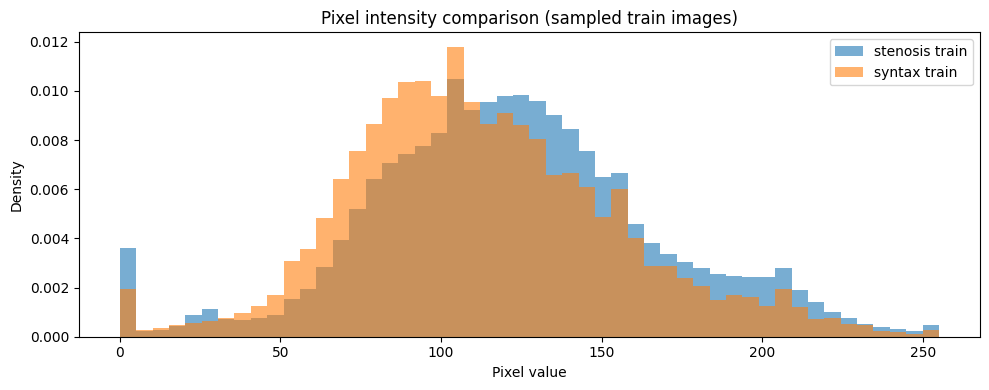

In [ ]:
# --- Plot 6: polygon complexity ---
complexity_rows = []

for item in all_data:
    task = item['task']
    split = item['split']
    coco = item['coco']

    point_counts = []

    for ann in coco['annotations']:
        seg = ann.get('segmentation', [])

        # Handle polygon only (skip RLE safely)
        if isinstance(seg, list):
            for poly in seg:
                if isinstance(poly, list) and len(poly) >= 6:
                    n_points = len(poly) // 2
                    point_counts.append(n_points)

    if not point_counts:
        point_counts = [0]

    complexity_rows.append({
        'task': task,
        'split': split,
        'mean_points': float(np.mean(point_counts)),
        'median_points': float(np.median(point_counts)),
        'p90_points': float(np.percentile(point_counts, 90))
    })


complexity_df = pd.DataFrame(complexity_rows)
display(complexity_df.sort_values(['task', 'split']))


# --- Plot ---
plt.figure(figsize=(10, 4))
for task in all_tasks:
    d = complexity_df[complexity_df['task'] == task].set_index('split').reindex(all_splits)
    plt.plot(all_splits, d['mean_points'], marker='o', label=f'{task} mean points')

plt.title('Polygon complexity by split')
plt.xlabel('Split')
plt.ylabel('Mean polygon points')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

import cv2  # IMPORTANT


def sample_intensities(task_name, max_images=120):
    item = next((x for x in all_data if x['task'] == task_name and x['split'] == 'train'), None)

    if item is None:
        print(f"⚠️ Missing data for {task_name}")
        return np.array([0], dtype=np.uint8)

    img_dir = item['img_dir']
    images = item['coco']['images']

    sample = images if len(images) <= max_images else random.sample(images, max_images)

    pixels = []

    for im in sample:
        img_path = img_dir / im['file_name']

        if not img_path.exists():
            continue

        arr = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        if arr is not None:
            pixels.append(arr.flatten())

    if not pixels:
        return np.array([0], dtype=np.uint8)

    return np.concatenate(pixels)


# --- Collect for all tasks ---
task_pixels = {}
for task in all_tasks:
    task_pixels[task] = sample_intensities(task)


# --- Plot ---
plt.figure(figsize=(10, 4))

for task, pixels in task_pixels.items():
    plt.hist(pixels, bins=50, alpha=0.6, density=True, label=f'{task} train')

plt.title('Pixel intensity comparison (sampled train images)')
plt.xlabel('Pixel value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ===================== LOAD DATA_INFO =====================

dataset_name = 'stenosis'  # change if needed


def load_split_info(split: str):
    img_dir, ann_path = get_split_paths(project_root, dataset_name, split)

    if not ann_path.exists():
        raise FileNotFoundError(f'Annotations not found: {ann_path}')

    coco = load_coco_json(ann_path)

    return {
        'task': dataset_name,
        'split': split,
        'img_dir': img_dir,
        'coco': coco,
        'image_lookup': build_image_lookup(coco),
        'anns_lookup': build_annotations_lookup(coco)
    }


data_info = {
    split: load_split_info(split)
    for split in ['train', 'val', 'test']
}

print("Loaded splits:", {k: len(v['coco']['images']) for k, v in data_info.items()})

Loaded splits: {'train': 1000, 'val': 200, 'test': 300}


In [ ]:
!pip install opencv-python albumentations scikit-learn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# ===================== IMPORTS =====================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models

import numpy as np
import random
import cv2
import os

from sklearn.metrics import confusion_matrix
import albumentations as A
from albumentations.pytorch import ToTensorV2

torch.backends.cudnn.benchmark = True

# ===================== CONFIG =====================
IMG_SIZE = 256
BATCH_SIZE = 4
LR = 1e-3
EPOCHS_SEG = 5
EPOCHS_CLS = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ===================== AUGMENTATION =====================
def get_transforms(train=True):
    if train:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomBrightnessContrast(p=0.3),
            A.GaussianBlur(p=0.2),
            A.Rotate(limit=20, p=0.3),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            ToTensorV2()
        ])


# ===================== MASK CREATION =====================
def coco_polygons_to_mask(annotations, height, width):
    mask = np.zeros((height, width), dtype=np.uint8)
    for ann in annotations:
        seg = ann.get('segmentation', [])
        if isinstance(seg, list):
            for poly in seg:
                pts = np.array(poly).reshape(-1, 2).astype(np.int32)
                if len(pts) >= 3:
                    cv2.fillPoly(mask, [pts], 1)
    return mask


# ===================== SEG DATASET =====================
class SegDataset(Dataset):
    def __init__(self, split):
        self.info = data_info[split]
        self.images = self.info['coco']['images']
        self.lookup = self.info['image_lookup']
        self.anns = self.info['anns_lookup']
        self.img_dir = self.info['img_dir']
        self.transforms = get_transforms(split == 'train')

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_item = self.images[idx]
        img_id = img_item['id']

        img = cv2.imread(str(self.img_dir / self.lookup[img_id]), 0)
        if img is None:
            raise FileNotFoundError()

        mask = coco_polygons_to_mask(
            self.anns.get(img_id, []),
            img.shape[0], img.shape[1]
        )

        aug = self.transforms(image=img, mask=mask)
        image = aug['image'].float() / 255.0
        mask = aug['mask'].unsqueeze(0).float()

        return image, mask.float()


# ===================== U-NET =====================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = DoubleConv(1, 32)
        self.d2 = DoubleConv(32, 64)
        self.d3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.bridge = DoubleConv(128, 256)

        self.u3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c3 = DoubleConv(256, 128)

        self.u2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c2 = DoubleConv(128, 64)

        self.u1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.c1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(self.pool(d1))
        d3 = self.d3(self.pool(d2))

        b = self.bridge(self.pool(d3))

        u3 = self.c3(torch.cat([self.u3(b), d3], 1))
        u2 = self.c2(torch.cat([self.u2(u3), d2], 1))
        u1 = self.c1(torch.cat([self.u1(u2), d1], 1))

        return self.out(u1)


# ===================== SEG TRAIN =====================
def dice_coeff(logits, targets):
    probs = torch.sigmoid(logits)
    inter = (probs * targets).sum()
    union = probs.sum() + targets.sum()
    return (2 * inter + 1e-6) / (union + 1e-6)


def train_seg(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        logits = model(x)
        bce = criterion(logits, y)
        dice = dice_coeff(logits, y)
        loss = 0.5 * bce + 0.5 * (1 - dice)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


# ===================== CLS DATASET (FUSION) =====================
class ClsDataset(Dataset):
    def __init__(self, split, seg_model):
        self.info = data_info[split]
        self.images = self.info['coco']['images']
        self.lookup = self.info['image_lookup']
        self.anns = self.info['anns_lookup']
        self.img_dir = self.info['img_dir']
        self.transforms = get_transforms(split == 'train')
        self.seg_model = seg_model.eval()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_item = self.images[idx]
        img_id = img_item['id']

        img = cv2.imread(str(self.img_dir / self.lookup[img_id]), 0)
        label = 1 if len(self.anns.get(img_id, [])) > 0 else 0

        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img_tensor = torch.tensor(img_resized / 255.0).float()[None].to(device)

        with torch.no_grad():
            mask = torch.sigmoid(self.seg_model(img_tensor.unsqueeze(0)))[0,0].cpu().numpy()

        img_resized = img_resized.astype(np.float32) / 255.0
        mask = mask.astype(np.float32)

        combined = np.stack([img_resized, mask, img_resized], axis=2).astype(np.float32)

        aug = self.transforms(image=combined)
        image = aug['image'].float()   # 🔥 force float32

        if image.dtype != torch.float32:
          image = image.float()

        return image, torch.tensor(label).float()


# ===================== CLASSIFIER =====================
def build_model():
    model = models.efficientnet_b0(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
    return model


# ===================== TRAIN CLS =====================
def train_cls(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        logits = model(x).squeeze(1)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def validate_cls(model, loader, criterion):
    model.eval()
    all_preds, all_targets = [], []
    total_loss = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x).squeeze(1)

            loss = criterion(logits, y)
            total_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).int()

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds, labels=[0, 1])

    # Safe accuracy calculation
    if cm.shape == (2, 2):
        acc = (cm[0,0] + cm[1,1]) / np.sum(cm)
    else:
        acc = np.trace(cm) / np.sum(cm)

    return total_loss / len(loader), acc, cm


# ===================== RUN TRAINING =====================
seg_train_loader = DataLoader(SegDataset('train'), batch_size=BATCH_SIZE, shuffle=True)
seg_model = UNet().to(device)

optimizer = torch.optim.Adam(seg_model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

for epoch in range(EPOCHS_SEG):
    loss = train_seg(seg_model, seg_train_loader, optimizer, criterion)
    print(f"[SEG] Epoch {epoch} Loss: {loss:.4f}")


cls_train_loader = DataLoader(ClsDataset('train', seg_model), batch_size=BATCH_SIZE, shuffle=True)
cls_val_loader = DataLoader(ClsDataset('val', seg_model), batch_size=BATCH_SIZE)

clf_model = build_model().to(device)
optimizer = torch.optim.Adam(clf_model.parameters(), lr=LR)

for epoch in range(EPOCHS_CLS):
    train_loss = train_cls(clf_model, cls_train_loader, optimizer, criterion)
    val_loss, acc, cm = validate_cls(clf_model, cls_val_loader, criterion)

    print(f"[CLS] Epoch {epoch} Train: {train_loss:.4f} Val: {val_loss:.4f} Acc: {acc:.4f}")
    print("Confusion Matrix:\n", cm)

Device: cuda
[SEG] Epoch 0 Loss: 0.5930
[SEG] Epoch 1 Loss: 0.4678
[SEG] Epoch 2 Loss: 0.4267
[SEG] Epoch 3 Loss: 0.4144
[SEG] Epoch 4 Loss: 0.4078
[CLS] Epoch 0 Train: 0.0399 Val: 0.0019 Acc: 1.0000
Confusion Matrix:
 [[  0   0]
 [  0 200]]
[CLS] Epoch 1 Train: 0.0228 Val: 0.0004 Acc: 1.0000
Confusion Matrix:
 [[  0   0]
 [  0 200]]
[CLS] Epoch 2 Train: 0.0312 Val: 0.0019 Acc: 1.0000
Confusion Matrix:
 [[  0   0]
 [  0 200]]
[CLS] Epoch 3 Train: 0.0244 Val: 0.0008 Acc: 1.0000
Confusion Matrix:
 [[  0   0]
 [  0 200]]
[CLS] Epoch 4 Train: 0.0270 Val: 0.0179 Acc: 0.9950
Confusion Matrix:
 [[  0   0]
 [  1 199]]


📸 Image: 159.png
🏷️ Annotations: 1


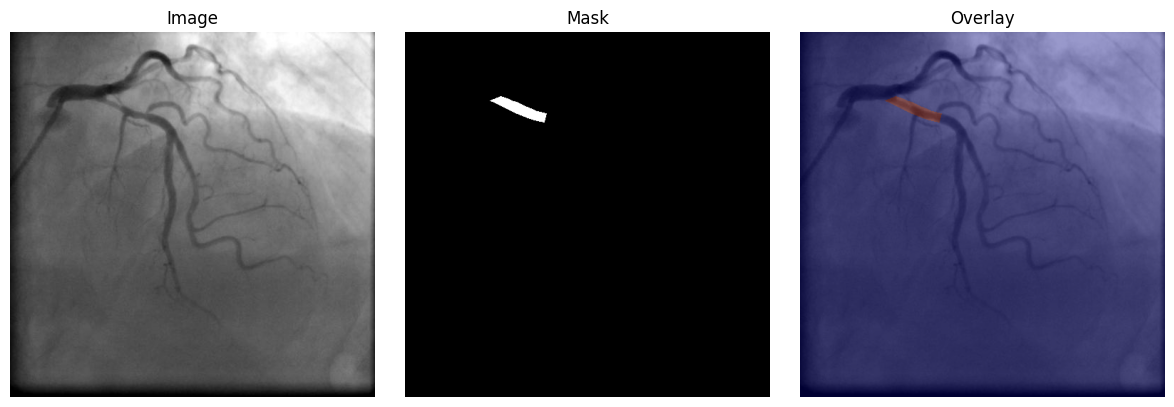

📸 Image: 644.png
🏷️ Annotations: 2


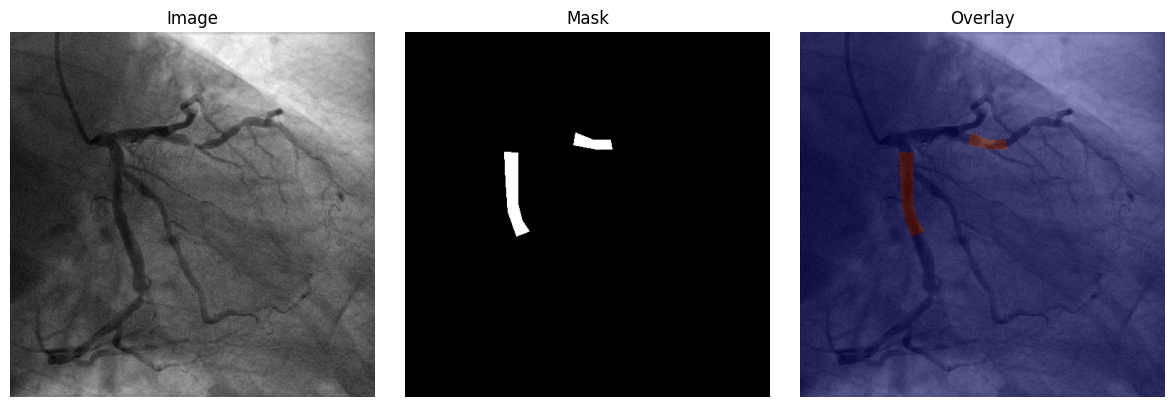

In [ ]:
def polygons_to_mask(annotations, height, width):
    mask = np.zeros((height, width), dtype=np.uint8)

    for ann in annotations:
        seg = ann.get('segmentation', [])

        if isinstance(seg, list):  # polygon format
            for poly in seg:
                pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
                pts = np.round(pts).astype(np.int32)

                if pts.shape[0] >= 3:
                    cv2.fillPoly(mask, [pts], 1)

        # Optional: handle RLE (skip for now if not needed)

    return mask


def show_random_overlay(split='train', only_annotated=False):
    split_info = data_info[split]
    coco = split_info['coco']
    image_lookup = split_info['image_lookup']
    anns_lookup = split_info['anns_lookup']
    img_dir = split_info['img_dir']

    # 🔥 Filter images if needed
    if only_annotated:
        valid_images = [img for img in coco['images']
                        if len(anns_lookup.get(img['id'], [])) > 0]
    else:
        valid_images = coco['images']

    if len(valid_images) == 0:
        print("⚠️ No valid images found")
        return

    img_item = random.choice(valid_images)
    img_id = img_item['id']
    file_name = image_lookup[img_id]

    img_path = img_dir / file_name
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"❌ Failed to load image: {img_path}")
        return

    anns = anns_lookup.get(img_id, [])
    mask = polygons_to_mask(anns, image.shape[0], image.shape[1])

    print(f"📸 Image: {file_name}")
    print(f"🏷️ Annotations: {len(anns)}")

    # --- Plot ---
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Mask')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(image, cmap='gray')
    plt.imshow(mask, cmap='jet', alpha=0.4)
    plt.title('Overlay')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

show_random_overlay('train', only_annotated=True)
show_random_overlay('train')

In [ ]:
# ===================== TEST EVALUATION (FUSION PIPELINE) =====================

from sklearn.metrics import confusion_matrix

# --- Build test loader using fusion dataset ---
test_dataset = ClsDataset('test', seg_model)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- Set models to eval mode ---
seg_model.eval()
clf_model.eval()

test_loss = 0.0
all_probs = []
all_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        targets = targets.to(device)

        # Forward pass through classifier (fusion already inside dataset)
        outputs = clf_model(images).squeeze(1)

        loss = criterion(outputs, targets)
        test_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy().tolist())
        all_targets.extend(targets.cpu().numpy().tolist())

# --- Final loss ---
test_loss = test_loss / max(len(test_loader.dataset), 1)

# --- Convert to predictions ---
test_preds = [1 if p >= 0.5 else 0 for p in all_probs]
test_targets = [int(t) for t in all_targets]

# --- Confusion matrix (robust) ---
cm = confusion_matrix(test_targets, test_preds, labels=[0, 1])

tn, fp, fn, tp = cm.ravel()

# --- Metrics ---
accuracy = (tp + tn) / max(len(test_targets), 1)
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = (2 * precision * recall) / max(precision + recall, 1e-9)

# --- Print results ---
print("\n===== TEST RESULTS (FUSION PIPELINE) =====")
print("Loss:", round(test_loss, 4))
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

print("\nConfusion Matrix:")
print(cm)
print(f"TP: {tp} | FP: {fp}")
print(f"FN: {fn} | TN: {tn}")


===== TEST RESULTS (FUSION PIPELINE) =====
Loss: 0.0031
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Confusion Matrix:
[[  0   0]
 [  0 300]]
TP: 300 | FP: 0
FN: 0 | TN: 0
